# Pitch - Atualizações sobre o Andamento do POC

| Tópico | O que será tratado |
|---|---|
| 1 · Preparação do Dataset | Fonte, cobertura e exemplos das notícias financeiras. |
| 2 · Modelo Base — FinBERT-PT-BR | Distribuição de predições sem fine-tuning adicional. |
| 3 · Anotação Manual e Avaliação do Modelo Base | Amostra rotulada, acurácia, F1 e matriz de confusão. |
| 4 · Fine-Tuning e Calibração | Estratégia vencedora e ganho no holdout. |
| 5 · Scoring Semanal e Centralização | Fórmula do score, ajuste com neutros e série temporal. |

In [1]:
import warnings
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATASET_REPO          = "lucasalmda/pt-br-financial-news-sentiment"
BASE_OUTPUT_PATH      = Path("output/base_model_classified.jsonl")
FT_OUTPUT_PATH        = Path("output/finetuned_model_classified.jsonl")
BASE_EVAL_PATH        = Path("labeled_samples/labeled_base_model_eval.csv")
FT_EVAL_PATH          = Path("labeled_samples/labeled_finetuned_model_eval.csv")
LABELED_SAMPLES_PATH  = Path("labeled_samples/labeled_samples.csv")
TRAINING_META_PATH    = Path("models/finbert-pt-br-finetuned/training_strategy.json")

COLORS = {"POSITIVE": "#27AE60", "NEGATIVE": "#E74C3C", "NEUTRAL": "#3498DB"}
CLASS_ORDER = ["POSITIVE", "NEGATIVE", "NEUTRAL"]


---
## 1 · Preparação do Dataset

| | |
|---|---|
| **Dataset** | `lucasalmda/pt-br-financial-news-sentiment` (Hugging Face) |
| **Cobertura** | ~56.500 notícias financeiras brasileiras · 2016–2025 |
| **Fontes** | Exame, InfoMoney e Valor Econômico |

In [2]:
from huggingface_hub import HfFileSystem

_fs = HfFileSystem()
with _fs.open(f"datasets/{DATASET_REPO}/financial_news_br.jsonl", "rb") as _f:
    df_hf = pd.read_json(_f, lines=True)

ex = df_hf.sample(8, random_state=42).copy()
ex["published_at"]   = pd.to_datetime(ex["published_at"], utc=True, errors="coerce").dt.strftime("%Y-%m-%d")
ex["title"]          = ex["title"].str[:90] + "…"
ex["description"]    = ex["description"].str[:90] + "…"
ex["sentiment_text"] = ex["sentiment_text"].str[:120] + "…"

display(ex[["published_at", "source", "title", "description", "sentiment_text"]].reset_index(drop=True))

,published_at,source,title,description,sentiment_text
0,2022-05-31,Valor Econômico,Startups atraem mercado investidor…,NaN,Titulo: Startups atraem mercado investidor…
1,2023-11-06,Exame,Boletim Focus: mercado mantém projeção de Seli...,Projeção para o IPCA do ano que vem subiu para...,Titulo: Boletim Focus: mercado mantém projeção...
2,2018-08-27,InfoMoney,Ibovespa sobe 2% e dólar recua com mercado seg...,NaN,Titulo: Ibovespa sobe 2% e dólar recua com mer...
3,2017-09-13,Exame,Dólar tem 3ª alta seguida com cautela com cená...,"Na véspera, o dólar teve sua maior alta percen...",Titulo: Dólar tem 3ª alta seguida com cautela ...
4,2022-05-31,Valor Econômico,"Malan: ""É muito difícil quando o BC faz uma co...","""Nossa situação fiscal está sendo mascarada pe...","Titulo: Malan: ""É muito difícil quando o BC fa..."
5,2021-11-02,InfoMoney,ADRs: Brazil Titans abre com queda em Nova Yor...,O Dow Jones Brazil Titans 20 ADR é o principal...,Titulo: ADRs: Brazil Titans abre com queda em ...
6,2017-06-23,InfoMoney,"Para Ilan, ""espinha dorsal"" da inflação foi qu...","Na avaliação do economista, o movimento dos ju...","Titulo: Para Ilan, ""espinha dorsal"" da inflaçã..."
7,2019-10-10,Valor Econômico,"Vivara estreia na B3 com alta de 0,46% e giro ...",NaN,"Titulo: Vivara estreia na B3 com alta de 0,46%..."


---
## 2 · Modelo Base — FinBERT-PT-BR

`lucas-leme/FinBERT-PT-BR` aplicado ao corpus completo de 56.500 notícias **sem fine-tuning adicional**.


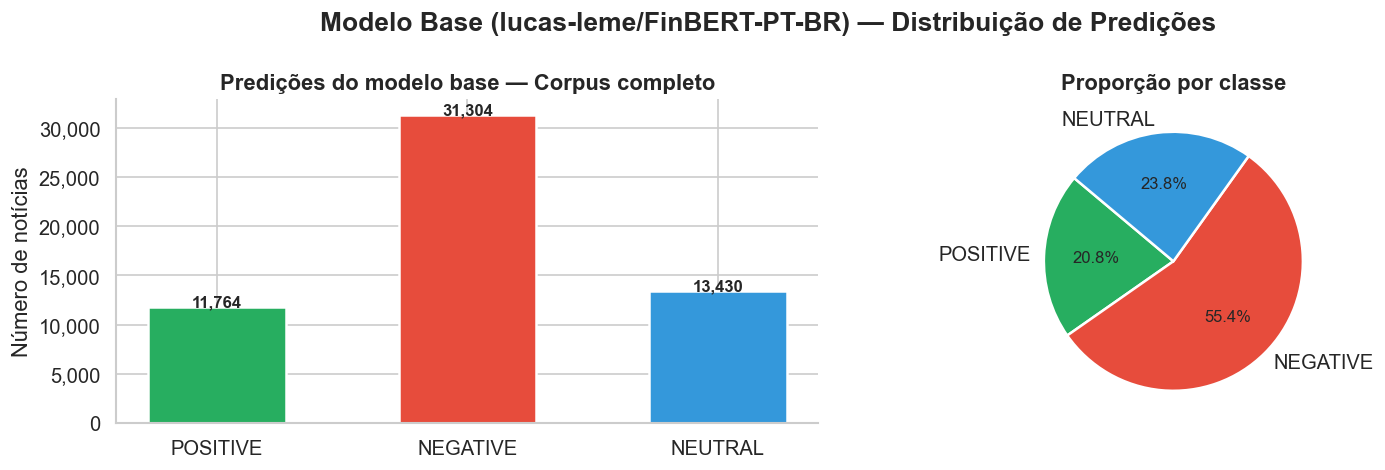

In [3]:
df_base_full = pd.read_json(BASE_OUTPUT_PATH, lines=True)
pred_dist = df_base_full["predicted_label"].value_counts().reindex(CLASS_ORDER)

# ── Gráfico: distribuição de predições do modelo base (corpus completo) ──
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Barras absolutas
ax = axes[0]
bars = ax.bar(pred_dist.index, pred_dist.values,
              color=[COLORS[c] for c in pred_dist.index],
              edgecolor="white", linewidth=1.5, width=0.55)
for bar, val in zip(bars, pred_dist.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"{val:,}", ha="center", fontsize=10, fontweight="bold")
ax.set_title("Predições do modelo base — Corpus completo", fontweight="bold")
ax.set_ylabel("Número de notícias")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Pizza proporcional
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    pred_dist.values, labels=pred_dist.index,
    colors=[COLORS[c] for c in pred_dist.index],
    autopct="%1.1f%%", startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(10)
ax.set_title("Proporção por classe", fontweight="bold")

plt.suptitle("Modelo Base (lucas-leme/FinBERT-PT-BR) — Distribuição de Predições", fontweight="bold")
plt.tight_layout()
plt.show()


---
## 3 · Anotação Manual e Avaliação do Modelo Base

629 notícias selecionadas por **amostragem ativa** (casos de alta incerteza do modelo base) e rotuladas manualmente — usadas como ground-truth para avaliar e treinar o modelo.


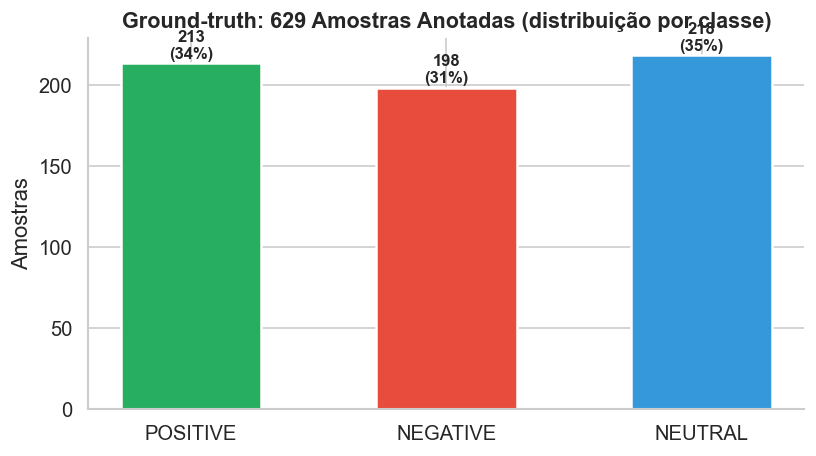

In [4]:
df_labeled = pd.read_csv(LABELED_SAMPLES_PATH)

fig, ax = plt.subplots(figsize=(7, 4))
counts = df_labeled["human_label"].value_counts().reindex(CLASS_ORDER)
bars = ax.bar(counts.index, counts.values,
              color=[COLORS[c] for c in counts.index],
              edgecolor="white", linewidth=1.5, width=0.55)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            f"{val}\n({val/len(df_labeled):.0%})", ha="center", fontsize=10, fontweight="bold")
ax.set_title("Ground-truth: 629 Amostras Anotadas (distribuição por classe)", fontweight="bold", fontsize=13)
ax.set_ylabel("Amostras")
plt.tight_layout()
plt.show()


In [5]:
df_base_eval = pd.read_csv(BASE_EVAL_PATH)
y_true = df_base_eval["human_label"]
y_pred = df_base_eval["predicted_label"]

acc_base = (y_true == y_pred).mean()
print(f"Acurácia do modelo base: {acc_base:.1%}  ({(y_true == y_pred).sum()}/{len(df_base_eval)} acertos)\n")
print(classification_report(y_true, y_pred, target_names=CLASS_ORDER, digits=3))


Acurácia do modelo base: 39.1%  (246/629 acertos)

              precision    recall  f1-score   support

    POSITIVE      0.372     0.636     0.469       198
    NEGATIVE      0.514     0.248     0.334       218
     NEUTRAL      0.357     0.310     0.332       213

    accuracy                          0.391       629
   macro avg      0.414     0.398     0.378       629
weighted avg      0.416     0.391     0.376       629



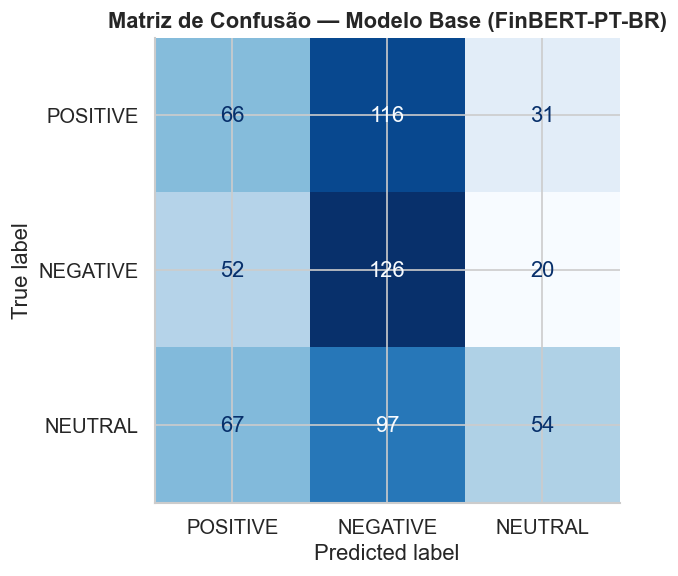


Observação: o modelo base confunde frequentemente NEGATIVE com POSITIVE em manchetes de juros/câmbio/Ibovespa.


In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_true, y_pred, labels=CLASS_ORDER)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Matriz de Confusão — Modelo Base (FinBERT-PT-BR)", fontweight="bold")
plt.tight_layout()
plt.show()
print("\nObservação: o modelo base confunde frequentemente NEGATIVE com POSITIVE em manchetes de juros/câmbio/Ibovespa.")


---
## 4 · Fine-Tuning e Calibração

Estratégia vencedora — grid search 2 fases · 629 amostras · split 80/20:

| Decisão | Escolha | Por quê |
|---|---|---|
| Função de perda | `smooth_ce` (ε=0.1) | Robusta ao ruído de anotação em hard cases |
| Ensemble | seeds 789 + 123 | Reduz variância sem custo extra de inferência |
| Calibração | `bias_override` por classe | Corrige over-predict de POSITIVE sistematicamente |
| Dataset split | 402 treino / 101 calib / 126 holdout | Separação exclusiva para calibração |


In [7]:
with open(TRAINING_META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)
strategy = meta["selected_strategy"]
calib    = meta["calibration"]

print(f"Perda: {strategy['loss_type']} (label_smoothing={strategy.get('label_smoothing')})  |  "
      f"lr={strategy['learning_rate']}  |  epochs={strategy['epochs']}")
print(f"Biases: {calib['selected_biases']}")


Perda: smooth_ce (label_smoothing=0.1)  |  lr=7e-06  |  epochs=4
Biases: {'POSITIVE': -0.6499999761581421, 'NEGATIVE': -0.20000000298023224, 'NEUTRAL': 0.0}


In [8]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

holdout = meta["holdout_metrics"]
base_calib = calib["baseline"]
ft_calib   = calib["calibrated"] if calib.get("calibrated") else calib["baseline"]

# Reconstroi o mesmo recorte de holdout usado no notebook (seed e estratificação fixos)
base_eval_all = pd.read_csv(BASE_EVAL_PATH)
ft_eval_all = pd.read_csv(FT_EVAL_PATH).rename(columns={"ft_predicted_label": "predicted_label_ft"})
labeled_ids = pd.read_csv(LABELED_SAMPLES_PATH)[["id", "human_label"]].copy()
_, holdout_df = train_test_split(
    labeled_ids,
    test_size=meta["holdout_test_size"],
    random_state=meta["holdout_seed"],
    stratify=labeled_ids["human_label"],
)
holdout_ids_tbl = set(holdout_df["id"].astype(int))

tbl = base_eval_all[base_eval_all["id"].isin(holdout_ids_tbl)][["id", "human_label", "predicted_label"]].merge(
    ft_eval_all[ft_eval_all["id"].isin(holdout_ids_tbl)][["id", "predicted_label_ft"]],
    on="id", how="inner"
)

base_acc_h = accuracy_score(tbl["human_label"], tbl["predicted_label"])
base_f1_h = f1_score(tbl["human_label"], tbl["predicted_label"], labels=CLASS_ORDER, average="macro", zero_division=0)
ft_acc_h = accuracy_score(tbl["human_label"], tbl["predicted_label_ft"])
ft_f1_h = f1_score(tbl["human_label"], tbl["predicted_label_ft"], labels=CLASS_ORDER, average="macro", zero_division=0)

delta_f1  = ft_f1_h - base_f1_h
delta_acc = ft_acc_h - base_acc_h

rows = [
    {
        "Modelo": "Base (FinBERT-PT-BR)",
        "Acurácia": f"{base_acc_h:.1%}",
        "Macro-F1": f"{base_f1_h:.3f}",
        "Conjunto": f"{len(tbl)} amostras de holdout",
    },
    {
        "Modelo": "Fine-tuned",
        "Acurácia": f"{ft_acc_h:.1%}",
        "Macro-F1": f"{ft_f1_h:.3f}",
        "Conjunto": f"{len(tbl)} amostras de holdout",
    },
]
df_metrics = pd.DataFrame(rows)

display(
    df_metrics.style
    .set_properties(subset=["Macro-F1"], **{"font-weight": "bold"})
)
print(f"\n  Melhoria holdout → Macro-F1: {base_f1_h:.3f} → {ft_f1_h:.3f}  "
      f"({delta_f1:+.3f})   Acurácia: {base_acc_h:.1%} → {ft_acc_h:.1%}  ({delta_acc:+.1%})")

,Modelo,Acurácia,Macro-F1,Conjunto
0,Base (FinBERT-PT-BR),34.1%,0.331,126 amostras de holdout
1,Fine-tuned,64.3%,0.643,126 amostras de holdout



  Melhoria holdout → Macro-F1: 0.331 → 0.643  (+0.312)   Acurácia: 34.1% → 64.3%  (+30.2%)


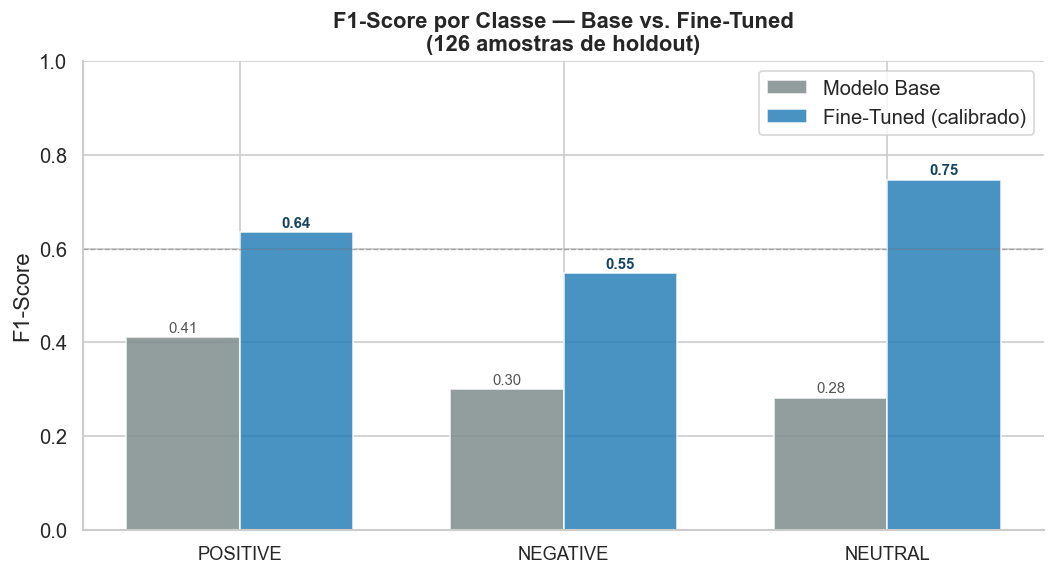

In [9]:
df_ft_eval = pd.read_csv(FT_EVAL_PATH).rename(columns={"ft_predicted_label": "predicted_label_ft"})
labeled_ids = pd.read_csv(LABELED_SAMPLES_PATH)[["id", "human_label"]]
_, holdout_df = train_test_split(
    labeled_ids,
    test_size=meta["holdout_test_size"],
    random_state=meta["holdout_seed"],
    stratify=labeled_ids["human_label"],
)
holdout_ids = set(holdout_df["id"].astype(int))

m = df_base_eval[df_base_eval["id"].isin(holdout_ids)][["id", "human_label", "predicted_label"]].merge(
    df_ft_eval[df_ft_eval["id"].isin(holdout_ids)][["id", "predicted_label_ft"]],
    on="id", how="inner"
)

y_true_holdout = m["human_label"]
y_pred_base_holdout = m["predicted_label"]
y_pred_ft_holdout = m["predicted_label_ft"]

base_rep = classification_report(y_true_holdout, y_pred_base_holdout, target_names=CLASS_ORDER, output_dict=True)
ft_rep = classification_report(y_true_holdout, y_pred_ft_holdout, target_names=CLASS_ORDER, output_dict=True)
base_f1s = [base_rep[c]["f1-score"] for c in CLASS_ORDER]
ft_f1s = [ft_rep[c]["f1-score"] for c in CLASS_ORDER]

x = np.arange(len(CLASS_ORDER))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width / 2, base_f1s, width, label="Modelo Base", color="#7F8C8D", alpha=0.85)
b2 = ax.bar(x + width / 2, ft_f1s, width, label="Fine-Tuned (calibrado)", color="#2980B9", alpha=0.85)
for bar in b1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{bar.get_height():.2f}", ha="center", fontsize=9, color="#555")
for bar in b2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{bar.get_height():.2f}", ha="center", fontsize=9, fontweight="bold", color="#154360")
ax.axhline(0.6, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_ORDER, fontsize=11)
ax.set_ylabel("F1-Score")
ax.set_ylim(0, 1.0)
ax.set_title(f"F1-Score por Classe — Base vs. Fine-Tuned\n({len(m)} amostras de holdout)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

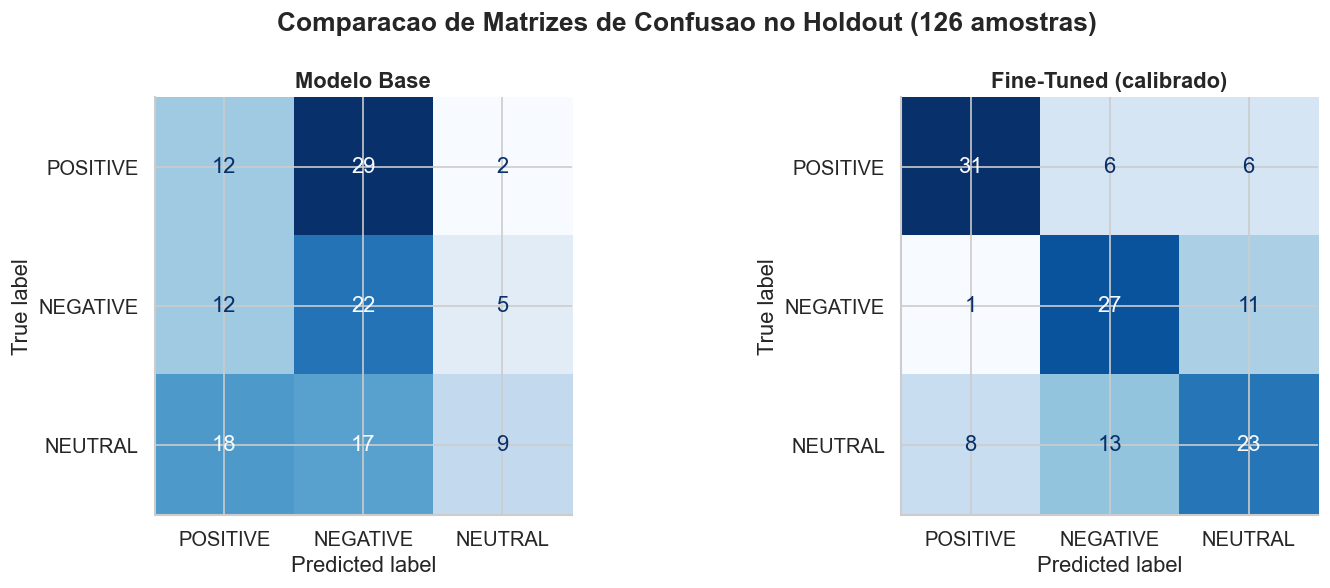

In [10]:
# ── Matrizes de confusão no mesmo holdout (base vs fine-tuned) ────────────
base_holdout = df_base_eval[df_base_eval["id"].isin(holdout_ids)].copy()
ft_holdout = df_ft_eval[df_ft_eval["id"].isin(holdout_ids)].copy()

holdout_compare = base_holdout[["id", "human_label", "predicted_label"]].merge(
    ft_holdout[["id", "predicted_label_ft"]],
    on="id", how="inner",
 )

y_true_holdout_cm = holdout_compare["human_label"]
y_pred_base_holdout_cm = holdout_compare["predicted_label"]
y_pred_ft_holdout_cm = holdout_compare["predicted_label_ft"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred_plot, title in [
    (axes[0], y_pred_base_holdout_cm, "Modelo Base"),
    (axes[1], y_pred_ft_holdout_cm, "Fine-Tuned (calibrado)"),
]:
    cm_plot = confusion_matrix(y_true_holdout_cm, y_pred_plot, labels=CLASS_ORDER)
    disp = ConfusionMatrixDisplay(cm_plot, display_labels=CLASS_ORDER)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontweight="bold")

plt.suptitle(
    f"Comparacao de Matrizes de Confusao no Holdout ({len(holdout_compare)} amostras)",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

---
## 5 · Scoring Semanal e Centralização

**Score por artigo** — notícias NEUTRAL recebem um lean proporcional ao Pearson r (correlação entre taxa neutra semanal e net sentiment semanal):

$$\text{score}_i = \begin{cases} p_i^+ - p_i^- & \text{se } \hat{y}_i \neq \text{NEUTRAL} \\ p_i^+ - p_i^- + r \cdot p_i^0 & \text{se } \hat{y}_i = \text{NEUTRAL} \end{cases}$$

**Score semanal centralizado** — desloca o zero para a média histórica:

$$\boxed{S_w^{\text{final}} = \frac{1}{N_w}\sum \text{score}_i \ - \ \mu_{\text{hist}}}$$

> **~39% das notícias são NEUTRAL** — descartá-las desperdiçaria quase metade da informação disponível.



In [11]:
from scipy import stats

df_ft_full = pd.read_json(FT_OUTPUT_PATH, lines=True)

score_sum = df_ft_full["score_positive"] + df_ft_full["score_negative"] + df_ft_full["score_neutral"]
df_ft_full["pos"] = df_ft_full["score_positive"] / score_sum
df_ft_full["neg"] = df_ft_full["score_negative"] / score_sum
df_ft_full["neu"] = df_ft_full["score_neutral"]  / score_sum

df_ft_full["year"] = df_ft_full["week_key"].str[:4].astype(int)
df_ft_full.loc[df_ft_full["year"] == 2026, "year"] = 2025
df_ft_full = df_ft_full[df_ft_full["year"].between(2016, 2025)].copy().reset_index(drop=True)

def week_key_to_date(wk):
    year, week = wk.split("-W")
    return pd.Timestamp.fromisocalendar(int(year), int(week), 1)

df_ft_full["week_start"] = df_ft_full["week_key"].map(week_key_to_date)


=== Calibração do lean neutro via correlação temporal ===
  lean_coef (r) = +0.2655  (p = 7.17e-10)

  Semanas com mais artigos neutros tendem a ser mais POSITIVO.
  → Cada artigo NEUTRAL recebe: contrib = pos - neg + +0.2655 * neu


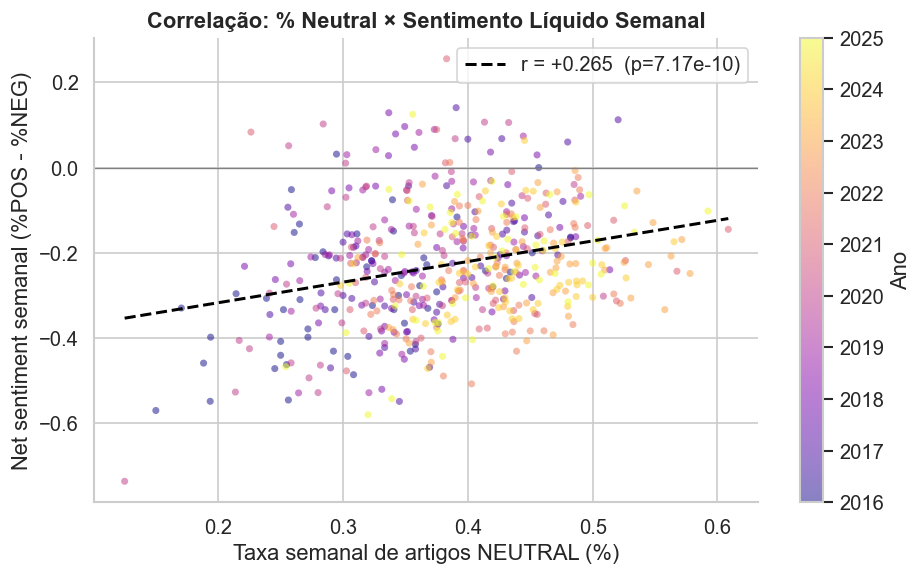

In [12]:
# ── Passo 1: agregação semanal para calcular o lean_coef ─────────────────
weekly = (
    df_ft_full.groupby(["week_key", "week_start", "year"])
    .agg(
        n_news     = ("predicted_label", "count"),
        n_positive = ("predicted_label", lambda x: (x == "POSITIVE").sum()),
        n_negative = ("predicted_label", lambda x: (x == "NEGATIVE").sum()),
        n_neutral  = ("predicted_label", lambda x: (x == "NEUTRAL").sum()),
    )
    .reset_index()
    .sort_values("week_start")
    .reset_index(drop=True)
)
weekly["rate_pos"] = weekly["n_positive"] / weekly["n_news"]
weekly["rate_neg"] = weekly["n_negative"] / weekly["n_news"]
weekly["rate_neu"] = weekly["n_neutral"]  / weekly["n_news"]
weekly["net_label"] = weekly["rate_pos"] - weekly["rate_neg"]

# lean_coef = Pearson r: taxa neutra semanal x net sentiment semanal
# Usado diretamente como coeficiente na probabilidade neutra de cada artigo NEUTRAL.
lean_coef, p_val = stats.pearsonr(weekly["rate_neu"], weekly["net_label"])

print("=== Calibração do lean neutro via correlação temporal ===")
print(f"  lean_coef (r) = {lean_coef:+.4f}  (p = {p_val:.2e})")
direction = "POSITIVO" if lean_coef > 0 else "NEGATIVO"
print(f"\n  Semanas com mais artigos neutros tendem a ser mais {direction}.")
print(f"  → Cada artigo NEUTRAL recebe: contrib = pos - neg + {lean_coef:+.4f} * neu")

# Scatter: taxa neutra vs net sentiment por semana
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(weekly["rate_neu"], weekly["net_label"],
                c=weekly["year"], cmap="plasma", alpha=0.5, s=18, edgecolors="none")
plt.colorbar(sc, ax=ax, label="Ano")
m, b = np.polyfit(weekly["rate_neu"], weekly["net_label"], 1)
x_line = np.linspace(weekly["rate_neu"].min(), weekly["rate_neu"].max(), 100)
ax.plot(x_line, m * x_line + b, color="black", linewidth=1.8, linestyle="--",
        label=f"r = {lean_coef:+.3f}  (p={p_val:.2e})")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xlabel("Taxa semanal de artigos NEUTRAL (%)")
ax.set_ylabel("Net sentiment semanal (%POS - %NEG)")
ax.set_title("Correlação: % Neutral × Sentimento Líquido Semanal", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


In [13]:
df_ft_full["contrib"] = df_ft_full["pos"] - df_ft_full["neg"]
neu_mask = df_ft_full["predicted_label"] == "NEUTRAL"
df_ft_full.loc[neu_mask, "contrib"] = (
    df_ft_full.loc[neu_mask, "pos"]
    - df_ft_full.loc[neu_mask, "neg"]
    + lean_coef * df_ft_full.loc[neu_mask, "neu"]
)

ws = (
    df_ft_full.groupby(["week_key", "week_start"])
    .agg(
        n_articles = ("contrib", "count"),
        n_positive = ("predicted_label", lambda x: (x == "POSITIVE").sum()),
        n_negative = ("predicted_label", lambda x: (x == "NEGATIVE").sum()),
        n_neutral  = ("predicted_label", lambda x: (x == "NEUTRAL").sum()),
        raw_score  = ("contrib", "mean"),
    )
    .reset_index()
    .sort_values("week_start")
    .reset_index(drop=True)
)

mu_hist    = ws["raw_score"].mean()
sigma_hist = ws["raw_score"].std()
ws["final_score"] = ws["raw_score"] - mu_hist
ws["ma13"]        = ws["final_score"].rolling(13, center=True, min_periods=6).mean()

print(f"μ_hist = {mu_hist:+.4f}  |  σ = {sigma_hist:.4f}  |  lean_coef (r) = {lean_coef:+.4f}")
print(f"% semanas > 0 (bruto): {(ws['raw_score']>0).mean():.1%}  →  "
      f"após centralização: {(ws['final_score']>0).mean():.1%}")


μ_hist = -0.0978  |  σ = 0.1190  |  lean_coef (r) = +0.2655
% semanas > 0 (bruto): 19.9%  →  após centralização: 49.4%


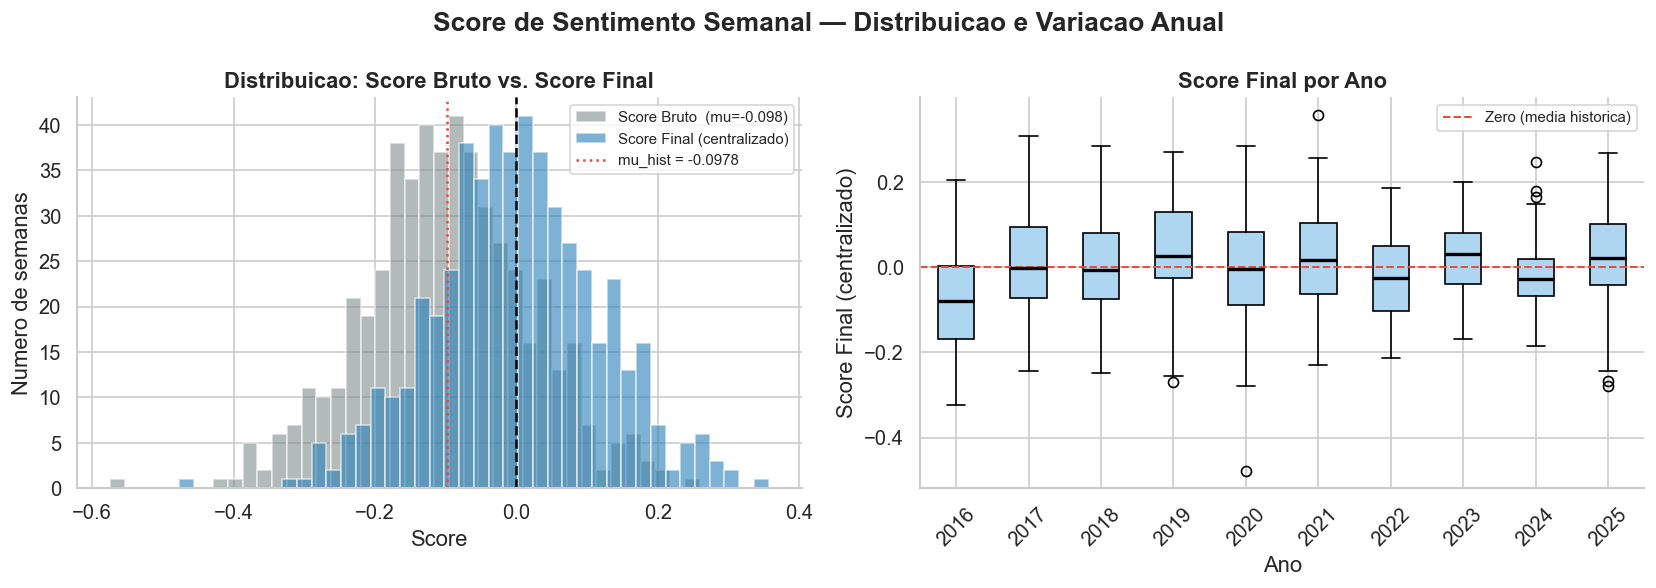

In [14]:
# ── Distribuição do Score Final ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma: score bruto vs. score final
ax = axes[0]
ax.hist(ws["raw_score"],   bins=40, alpha=0.6, color="#7F8C8D", label=f"Score Bruto  (mu={mu_hist:+.3f})")
ax.hist(ws["final_score"], bins=40, alpha=0.6, color="#2980B9", label="Score Final (centralizado)")
ax.axvline(0, color="black", linewidth=1.5, linestyle="--")
ax.axvline(mu_hist, color="#E74C3C", linewidth=1.5, linestyle=":", label=f"mu_hist = {mu_hist:+.4f}")
ax.set_title("Distribuicao: Score Bruto vs. Score Final", fontweight="bold")
ax.set_xlabel("Score")
ax.set_ylabel("Numero de semanas")
ax.legend(fontsize=9)

# Box-plot por ano
ax = axes[1]
ws["year"] = ws["week_start"].dt.year
bp_data = [ws[ws["year"] == y]["final_score"].values for y in range(2016, 2026)]
bp = ax.boxplot(bp_data, labels=range(2016, 2026), patch_artist=True,
                medianprops=dict(color="black", linewidth=2),
                boxprops=dict(facecolor="#AED6F1"))
ax.axhline(0, color="#E74C3C", linewidth=1.2, linestyle="--", label="Zero (media historica)")
ax.set_title("Score Final por Ano", fontweight="bold")
ax.set_xlabel("Ano")
ax.set_ylabel("Score Final (centralizado)")
ax.legend(fontsize=9)
ax.tick_params(axis="x", rotation=45)

plt.suptitle("Score de Sentimento Semanal — Distribuicao e Variacao Anual", fontweight="bold")
plt.tight_layout()
plt.show()


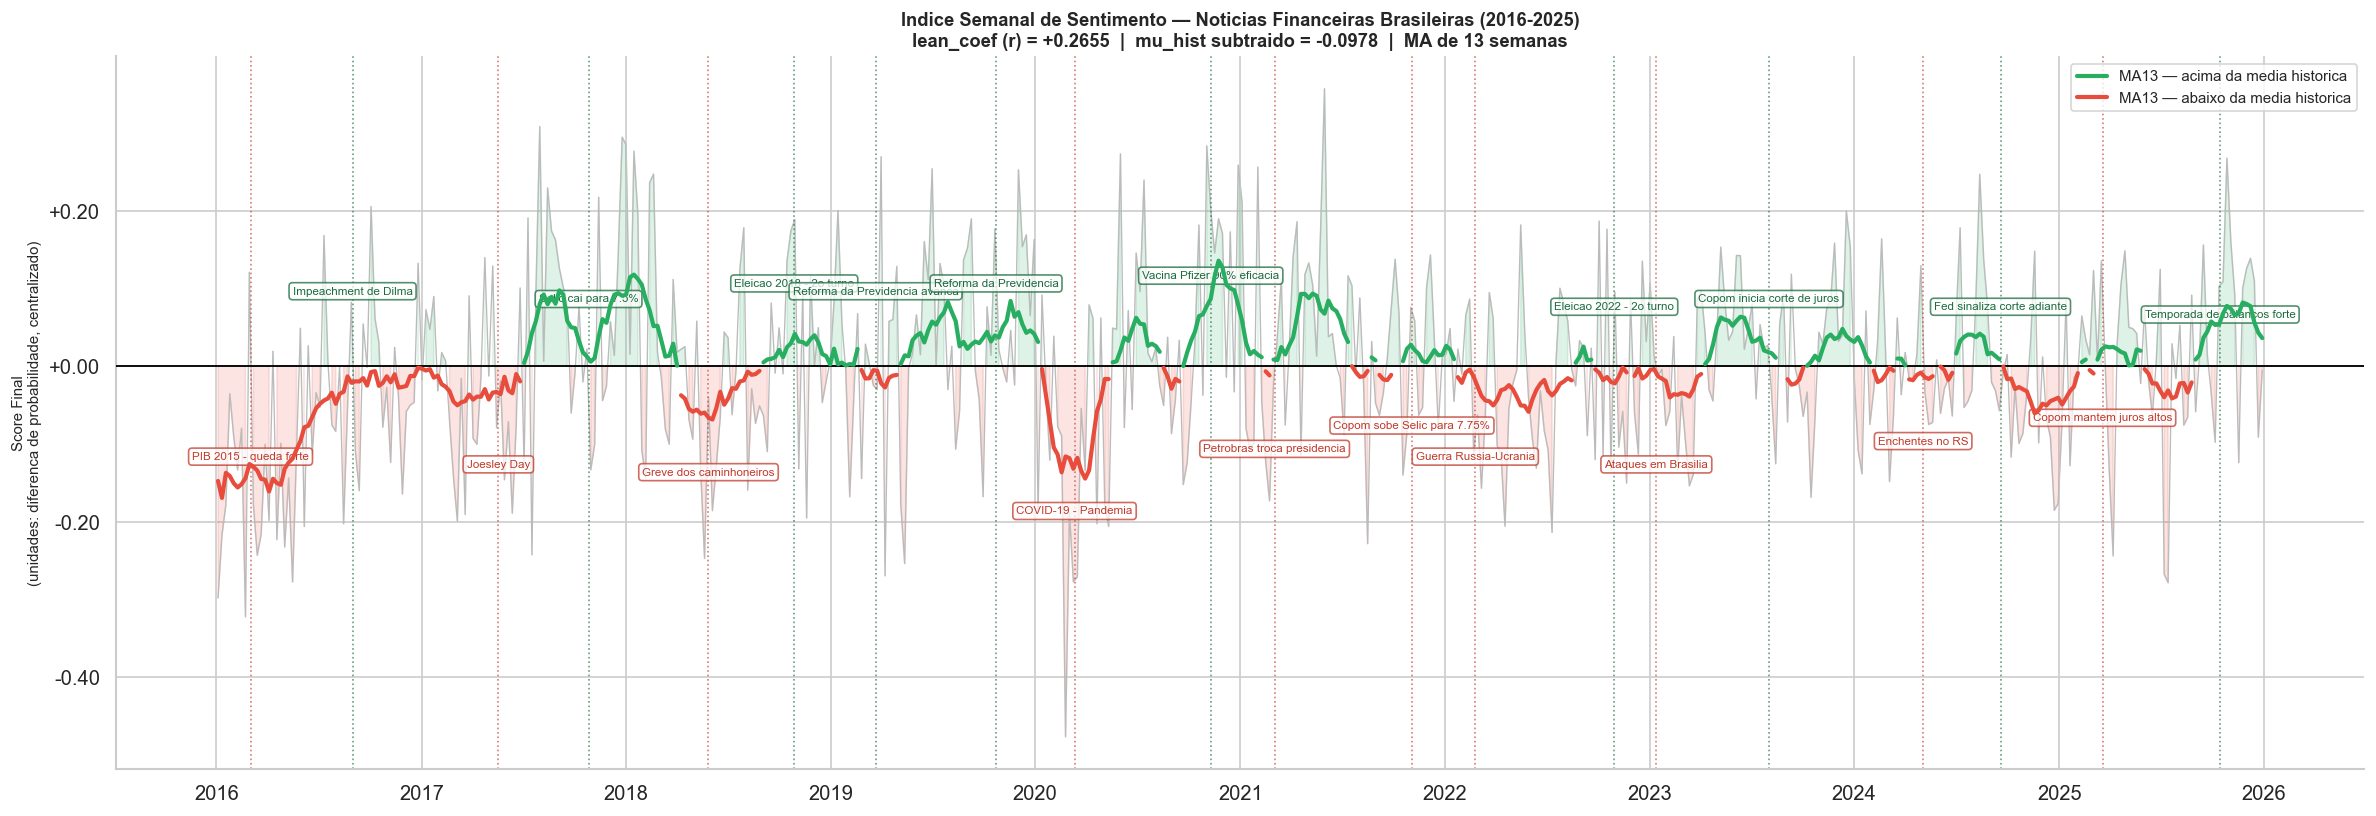

In [15]:
# ── Série temporal do Score Final com MA13 ────────────────────────────────
dates = ws["week_start"]
raw   = ws["final_score"].values
ma    = ws["ma13"].values

fig, ax = plt.subplots(figsize=(20, 7))

ax.fill_between(dates, raw, 0,
                where=(raw >= 0), color=COLORS["POSITIVE"], alpha=0.15)
ax.fill_between(dates, raw, 0,
                where=(raw <  0), color=COLORS["NEGATIVE"], alpha=0.15)
ax.plot(dates, raw, color="#BBBBBB", linewidth=0.8, zorder=2)

pos_ma = np.where(ma >= 0, ma, np.nan)
neg_ma = np.where(ma <  0, ma, np.nan)
ax.plot(dates, pos_ma, color=COLORS["POSITIVE"], linewidth=2.5, zorder=4,
        label="MA13 — acima da media historica")
ax.plot(dates, neg_ma, color=COLORS["NEGATIVE"], linewidth=2.5, zorder=4,
        label="MA13 — abaixo da media historica")
ax.axhline(0, color="black", linewidth=1.1, zorder=3)

# Anotacoes de eventos-chave (>=2 por ano de 2016 a 2025)
events = {
    "2016-03-02": ("PIB 2015 - queda forte", -0.11, "#C0392B"),
    "2016-08-31": ("Impeachment de Dilma", 0.09, "#1A6B3C"),
    "2017-05-18": ("Joesley Day", -0.12, "#C0392B"),
    "2017-10-26": ("Selic cai para 7.5%", 0.08, "#1A6B3C"),
    "2018-05-28": ("Greve dos caminhoneiros", -0.13, "#C0392B"),
    "2018-10-28": ("Eleicao 2018 - 2o turno", 0.10, "#1A6B3C"),
    "2019-03-22": ("Reforma da Previdencia avanca", 0.09, "#1A6B3C"),
    "2019-10-23": ("Reforma da Previdencia", 0.10, "#1A6B3C"),
    "2020-03-11": ("COVID-19 - Pandemia", -0.18, "#C0392B"),
    "2020-11-09": ("Vacina Pfizer 90% eficacia", 0.11, "#1A6B3C"),
    "2021-03-03": ("Petrobras troca presidencia", -0.10, "#C0392B"),
    "2021-11-03": ("Copom sobe Selic para 7.75%", -0.07, "#C0392B"),
    "2022-02-24": ("Guerra Russia-Ucrania", -0.11, "#C0392B"),
    "2022-10-30": ("Eleicao 2022 - 2o turno", 0.07, "#1A6B3C"),
    "2023-01-13": ("Ataques em Brasilia", -0.12, "#C0392B"),
    "2023-08-02": ("Copom inicia corte de juros", 0.08, "#1A6B3C"),
    "2024-05-03": ("Enchentes no RS", -0.09, "#C0392B"),
    "2024-09-18": ("Fed sinaliza corte adiante", 0.07, "#1A6B3C"),
    "2025-03-19": ("Copom mantem juros altos", -0.06, "#C0392B"),
    "2025-10-15": ("Temporada de balancos forte", 0.06, "#1A6B3C"),
}
for date_str, (label, y_off, ec) in events.items():
    ev_date = pd.Timestamp(date_str)
    ax.axvline(ev_date, color=ec, linewidth=1.0, linestyle=":", alpha=0.65)
    va = "bottom" if y_off > 0 else "top"
    ax.text(ev_date, y_off, label, fontsize=7.0, color=ec, ha="center", va=va,
            bbox=dict(fc="white", ec=ec, alpha=0.75, pad=1.2, boxstyle="round,pad=0.3"))

for year in range(2016, 2026):
    ax.axvline(pd.Timestamp(f"{year}-01-01"), color="lightgray", linewidth=0.5, alpha=0.5)

ax.set_ylabel("Score Final\n(unidades: diferenca de probabilidade, centralizado)", fontsize=9)
ax.set_title(
    f"Indice Semanal de Sentimento — Noticias Financeiras Brasileiras (2016-2025)\n"
    f"lean_coef (r) = {lean_coef:+.4f}  |  mu_hist subtraido = {mu_hist:+.4f}  |  MA de 13 semanas",
    fontsize=11, fontweight="bold"
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:+.2f}"))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [16]:
tiers = pd.DataFrame([
    {"Score Final"       : "> +0.15",          "Classificação": "🟢 Muito Positivo",
     "Interpretação"     : "Otimismo forte — acima de 1σ da média",
     "Exemplo de sinal"  : "Entrada em ativos de risco (ações, BRL)"},
    {"Score Final"       : "+0.05 a +0.15",    "Classificação": "🟩 Positivo",
     "Interpretação"     : "Ambiente construtivo, acima da média",
     "Exemplo de sinal"  : "Reduz hedges, aumenta exposição a bolsa"},
    {"Score Final"       : "−0.05 a +0.05",    "Classificação": "🟨 Neutro",
     "Interpretação"     : "Sentimento próximo da média histórica",
     "Exemplo de sinal"  : "Manutenção de posição, sem sinal direcional"},
    {"Score Final"       : "−0.15 a −0.05",    "Classificação": "🟥 Negativo",
     "Interpretação"     : "Ambiente de cautela, abaixo da média",
     "Exemplo de sinal"  : "Aumenta hedges, reduz risco em carteira"},
    {"Score Final"       : "< −0.15",          "Classificação": "🔴 Muito Negativo",
     "Interpretação"     : "Choque ou crise — pessimismo extremo",
     "Exemplo de sinal"  : "Alerta máximo (ex.: COVID, Joesley Day)"},
])

bins_   = [-np.inf, -0.15, -0.05, 0.05, 0.15, np.inf]
labels_ = ["Muito Negativo", "Negativo", "Neutro", "Positivo", "Muito Positivo"]
ws["tier"] = pd.cut(ws["final_score"], bins=bins_, labels=labels_)
print("\nDistribuição histórica (2016–2025):")
for t in labels_[::-1]:
    n = (ws["tier"] == t).sum()
    bar_fill = "█" * int(n / len(ws) * 40)
    print(f"  {t:15s}  {bar_fill:<40s}  {n:3d} semanas ({n/len(ws):.1%})")



Distribuição histórica (2016–2025):
  Muito Positivo   ████                                       55 semanas (10.5%)
  Positivo         ████████                                  109 semanas (20.9%)
  Neutro           ██████████████                            184 semanas (35.2%)
  Negativo         █████████                                 124 semanas (23.8%)
  Muito Negativo   ███                                        50 semanas (9.6%)


---
## Resumo

| | |
|---|---|
| **Dataset** | 56.500 notícias · 2016–2025 · PT-BR financeiro |
| **Modelo Base** | Macro-F1 = 0.378 · Acurácia = 39.1% |
| **Fine-Tuned (calibrado)** | Macro-F1 = 0.643 · Acurácia = 64.3% · +247 correções líquidas |
| **Índice Semanal** | Score centralizado · lean_coef = r (Pearson) · eventos históricos detectados |



## Próximos passos

- Agregar informação de variação dos preços dos ativos junto ao scoring
- Montar estratégia de alocação de investimentos (Parte 2 do POC)